# Honeycomb Tight-Binding Model

Let's setup the problem class using the honeycomb data json.

In [16]:
from acceptor_TI import Problem

data_path = "../../acceptor_TI/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [17]:
sub_1, sub_2 = ["A", "B"], ["B", "A"]
for sub_label, nn_label in zip(sub_1, sub_2):
    parser = getattr(problem.cell_parser.eigenvalues, sub_label).value
    parser["nn_hopping"][nn_label]["t_ss_sigma"] = -1
    parser["nn_hopping"][nn_label]["t_sp_sigma"] = 1
    parser["nn_hopping"][nn_label]["t_pp_sigma"] = 1
    parser["nn_hopping"][nn_label]["t_pp_pi"] = -1.4

In [18]:
location = "bulk"
problem.setup(
    N_r = 10,            # size of lattice in real space
    N_k = 300,           # reciprocal space discretization
    location = location  # location of where to calculate eigenvalues
)

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.


## Clebsch-Gordan Coefficients

In [19]:
tb = problem.hamiltonian[location]["tight_binding"]

tb.CG_coefficients

{'|0,0;0.5,-0.5>': 0.707106781186548*sqrt(2),
 '|0,0;0.5,0.5>': 0.707106781186548*sqrt(2),
 '|1,-1;0.5,-0.5>': 1.00000000000000,
 '|1,-1;0.5,0.5>': 0.333333333333333*sqrt(3),
 '|1,0;0.5,-0.5>': 0.333333333333333*sqrt(6),
 '|1,0;0.5,0.5>': 0.333333333333333*sqrt(6),
 '|1,1;0.5,-0.5>': 0.333333333333333*sqrt(3),
 '|1,1;0.5,0.5>': 1.00000000000000}

In [20]:
tb.sublattice_data_dict["A"].keys()
sublattice = list(tb.sublattice_data_dict["A"].keys())[0]

## Coupled Angular Momentum States

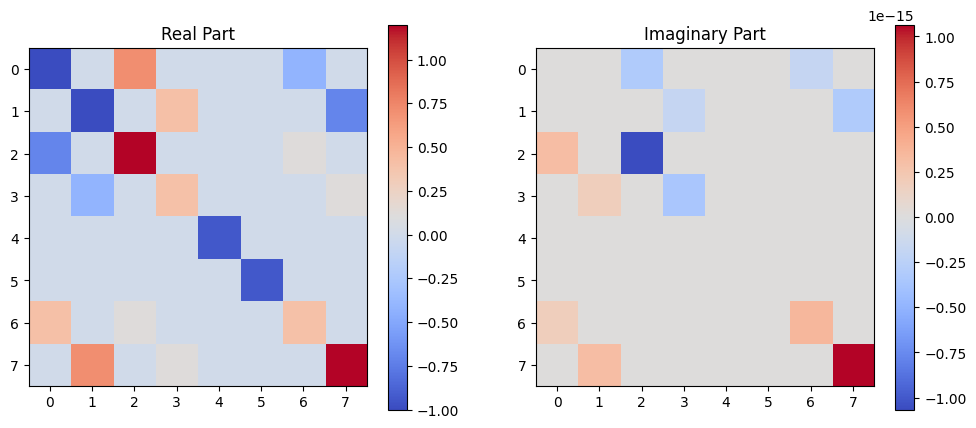

In [21]:
if location == "bulk":
    idx = tb.sublattice_data_dict["A"]["neighbour_idxs"][0]
    tb._visualise_matrix(tb.sublattice_data_dict["A"]['hopping_dict'][idx])
elif location == "edge":
    idx = tb.sublattice_data_dict["A"][sublattice]["neighbour_idxs"][0]
    tb._visualise_matrix(tb.sublattice_data_dict["A"][sublattice]['hopping_dict'][idx])

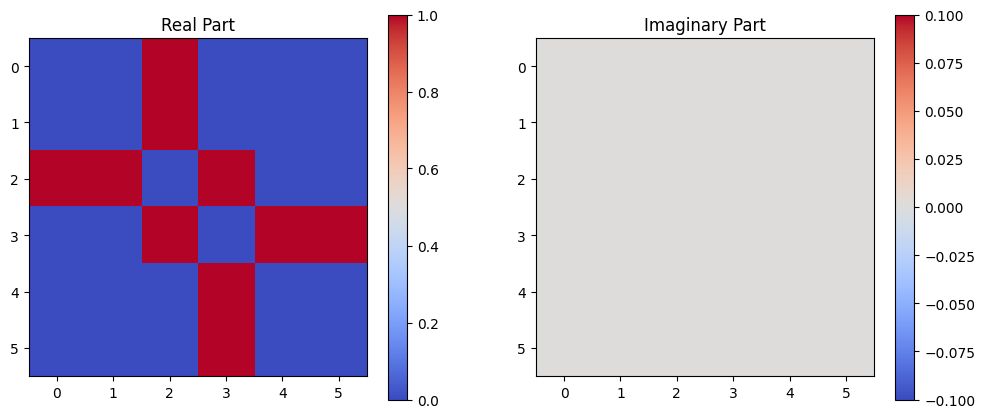

In [22]:
tb._visualise_matrix(tb.sublattice_connectivity)

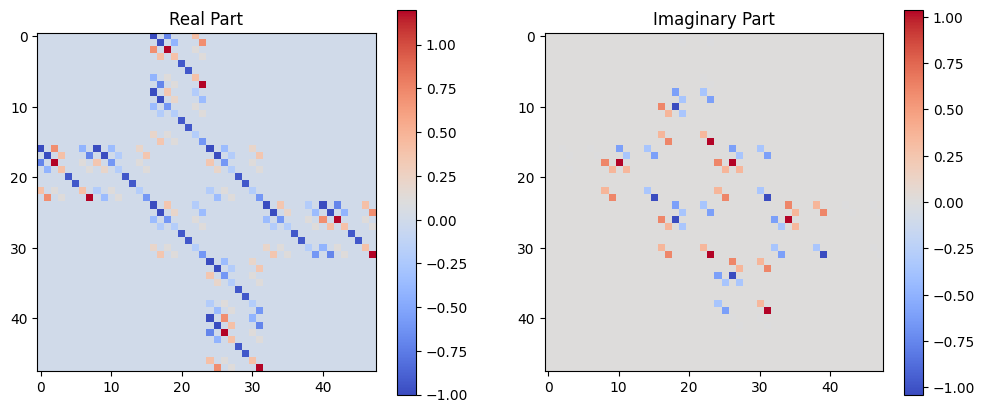

In [23]:
tb._visualise_matrix(tb.H)